# Acknowledgment 

I would like to express my sincere gratitude to **Professor David** for his dedicated time, continuous guidance, and commitment throughout this module. His ability to explain the topics using different teaching approaches and practical examples greatly supported our understanding and helped make complex concepts clearer and more accessible.

I would also like to extend my appreciation to my supportive and professional colleagues, **Jahjah, Boualem, and Tahir**. Working with them was a very positive and valuable experience. Their collaboration, knowledge-sharing, and encouragement created a productive learning environment. I was truly happy to work with them, and I learned a lot from their different perspectives, professional experiences, and teamwork.

This module has been a meaningful learning journey, and I am grateful for the support, guidance, and collaboration that contributed to my overall understanding and development.

# Week 5 & Final Project Solution  
## Case Study 2: Cryptocurrency Price Forecasting — Bitcoin Next-Day Closing Price

**Project Description:**  
This project forecasts the next-day closing price of Bitcoin using historical daily market data. Two deep learning models are compared: a **Multi-Layer Perceptron (MLP)** and a **Long Short-Term Memory (LSTM)** network.

**Dataset:** `Bitcoin_Daily.csv`  
The dataset contains daily Bitcoin market information including timestamp, open, high, low, close, and volume.

**Target Variable:** `close`  
The model predicts the next-day Bitcoin closing price using the previous 30 days of closing prices.

**Models Used:**  
1. MLP model using flattened 30-day price windows.  
2. LSTM model using 30-day sequential input.

**Evaluation Metrics:**  
- Mean Squared Error (MSE)  
- Mean Absolute Error (MAE)  
- Mean Absolute Percentage Error (MAPE)

**How to Run:**  
Run the notebook from top to bottom in Jupyter Notebook, JupyterLab, VS Code, or Google Colab. Make sure the CSV file is in the same folder as this notebook.

## Part 1: Import Required Libraries

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `import pandas as pd` | Imports pandas, which is used to load and manage tabular data such as CSV files. |
| `import numpy as np` | Imports NumPy, which is used for numerical arrays and mathematical operations. |
| `import matplotlib.pyplot as plt` | Imports Matplotlib for creating charts and visualisations. |
| `from sklearn.preprocessing import MinMaxScaler` | Imports MinMaxScaler to scale Bitcoin prices between 0 and 1. |
| `from sklearn.metrics import mean_squared_error, mean_absolute_error` | Imports evaluation metrics used to measure prediction error. |
| `import torch` | Imports PyTorch, the deep learning framework used to build and train the models. |
| `import torch.nn as nn` | Imports PyTorch neural network layers such as Linear and LSTM. |
| `from torch.utils.data import TensorDataset, DataLoader` | Imports tools to convert tensors into mini-batches for model training. |
| `import random` | Imports Python's random module so that results can be made more reproducible. |
| `pd.set_option(...)` | Adjusts pandas display settings so tables are easier to read. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import random

torch.set_num_threads(1)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Part 2: Reproducibility Settings

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `SEED = 42` | Creates a fixed seed value so model results are more consistent each time the notebook is run. |
| `random.seed(SEED)` | Fixes randomness for Python's random module. |
| `np.random.seed(SEED)` | Fixes randomness for NumPy operations. |
| `torch.manual_seed(SEED)` | Fixes randomness for PyTorch model initialization and training. |
| `device = torch.device(...)` | Uses GPU if available; otherwise, it uses CPU. |
| `print(...)` | Displays whether the notebook is running on CPU or GPU. |

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Part 3: Load the Bitcoin Dataset

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `CSV_PATH = "Bitcoin_Daily.csv"` | Stores the dataset file name in a variable. |
| `df = pd.read_csv(CSV_PATH)` | Reads the CSV file and stores it in a pandas DataFrame called `df`. |
| `print("Dataset shape:", df.shape)` | Displays the number of rows and columns in the dataset. |
| `display(df.head())` | Displays the first five rows to confirm the dataset loaded correctly. |

In [3]:
CSV_PATH = "Bitcoin_Daily.csv"
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1674, 6)


,timestamp,open,high,low,close,volume
0,2019-01-01,3701.23,3810.16,3642.00,3797.14,29493.893940
1,2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2,2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
3,2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
4,2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


## Part 4: Check Data Types and Missing Values

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `print("Data types:")` | Prints a heading for the data type output. |
| `print(df.dtypes)` | Displays the type of each column, such as object or float. |
| `print("Missing values:")` | Prints a heading for missing value checks. |
| `print(df.isna().sum())` | Counts missing values in each column. |
| `display(df.describe())` | Shows descriptive statistics for numerical columns. |

In [4]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

display(df.describe())

Data types:
timestamp     object
open         float64
high         float64
low          float64
close        float64
volume       float64
dtype: object

Missing values:
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


,open,high,low,close,volume
count,1674.000000,1674.000000,1674.000000,1674.000000,1674.000000
mean,23826.260191,24446.346302,23141.704301,23841.391380,90492.866809
std,16474.464732,16932.258079,15937.256978,16467.689321,93496.285584
min,3398.400000,3426.450000,3349.920000,3398.400000,10851.368440
25%,9390.600000,9588.250000,9211.455000,9396.917500,37840.367112
50%,20018.950000,20424.090000,19544.545000,20043.810000,56891.096851
75%,36009.072500,37542.552500,34395.287500,36009.072500,93691.800425
max,67525.820000,69000.000000,66222.400000,67525.830000,760705.362783


## Part 5: Convert Timestamp and Sort Chronologically

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `df["timestamp"] = pd.to_datetime(df["timestamp"])` | Converts the timestamp column from text into a real date format. |
| `df = df.sort_values("timestamp")` | Sorts the records from oldest to newest date. |
| `df = df.reset_index(drop=True)` | Resets the row index after sorting. |
| `print(...)` | Displays the first and last date in the dataset. |
| `display(df.head())` | Displays the first rows after sorting. |

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df = df.reset_index(drop=True)

print("Date range:", df["timestamp"].min().date(), "to", df["timestamp"].max().date())
display(df.head())

Date range: 2019-01-01 to 2023-08-01


,timestamp,open,high,low,close,volume
0,2019-01-01,3701.23,3810.16,3642.00,3797.14,29493.893940
1,2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2,2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
3,2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
4,2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


## Part 6: Plot Daily Closing Price Trend

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `plt.figure(figsize=(12,5))` | Creates a chart with a suitable size. |
| `plt.plot(...)` | Draws the Bitcoin closing price over time. |
| `plt.title(...)` | Adds a title to the chart. |
| `plt.xlabel(...)` | Labels the x-axis as the date. |
| `plt.ylabel(...)` | Labels the y-axis as closing price in USD. |
| `plt.grid(True)` | Adds grid lines to make the chart easier to read. |
| `plt.show()` | Displays the chart. |

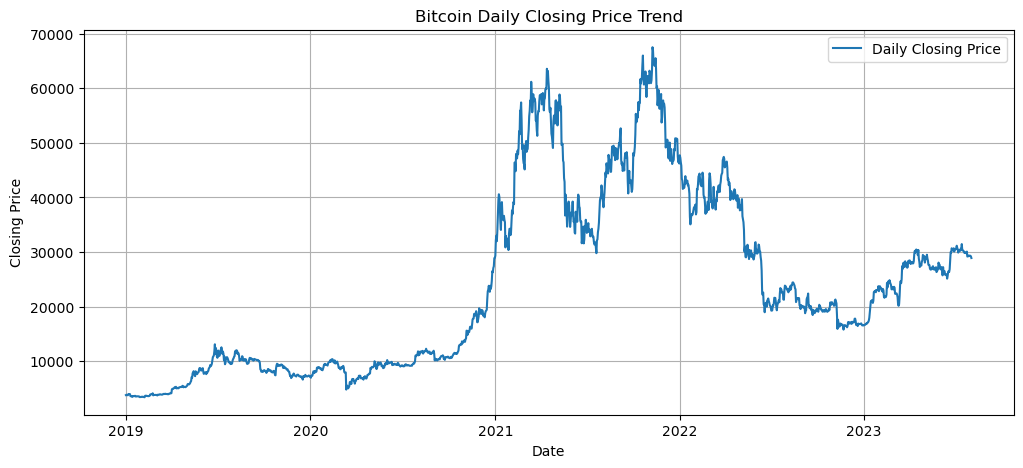

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["close"], label="Daily Closing Price")
plt.title("Bitcoin Daily Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.legend()
plt.show()

## Part 7: Plot 7-Day and 30-Day Moving Averages

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `df["MA7"] = ...` | Calculates the 7-day moving average to show short-term price momentum. |
| `df["MA30"] = ...` | Calculates the 30-day moving average to show longer-term trend direction. |
| `plt.figure(...)` | Creates a chart area. |
| `plt.plot(... close ...)` | Plots the original daily closing price. |
| `plt.plot(... MA7 ...)` | Plots the 7-day moving average. |
| `plt.plot(... MA30 ...)` | Plots the 30-day moving average. |
| `plt.title(...)` | Adds a chart title. |
| `plt.xlabel(...)` and `plt.ylabel(...)` | Add axis labels. |
| `plt.legend()` | Displays labels for each line. |
| `plt.grid(True)` | Adds grid lines. |
| `plt.show()` | Displays the chart. |

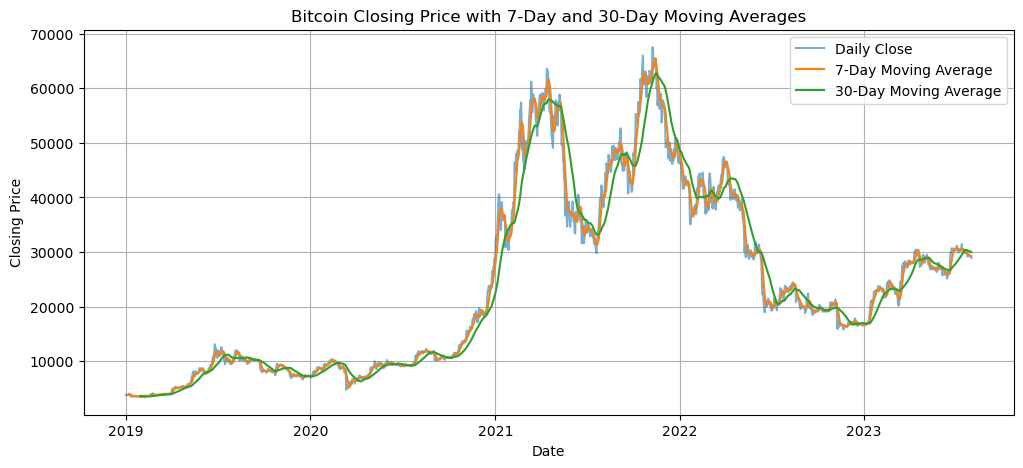

In [7]:
df["MA7"] = df["close"].rolling(window=7).mean()
df["MA30"] = df["close"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["close"], label="Daily Close", alpha=0.6)
plt.plot(df["timestamp"], df["MA7"], label="7-Day Moving Average")
plt.plot(df["timestamp"], df["MA30"], label="30-Day Moving Average")
plt.title("Bitcoin Closing Price with 7-Day and 30-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

## Part 8: Scale the Closing Price

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `close_values = df[["close"]].values` | Extracts only the close column as a two-dimensional NumPy array. |
| `scaler = MinMaxScaler(feature_range=(0, 1))` | Creates a scaler that transforms prices into the range 0 to 1. |
| `scaled_close = scaler.fit_transform(close_values)` | Learns the minimum and maximum values, then scales the close prices. |
| `print(...)` | Displays the minimum and maximum scaled values. |

In [8]:
close_values = df[["close"]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_values)

print("Scaled close minimum:", scaled_close.min())
print("Scaled close maximum:", scaled_close.max())

Scaled close minimum: 0.0
Scaled close maximum: 1.0


## Part 9: Create 30-Day Lookback Sequences

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `SEQ_LEN = 30` | Sets the lookback window to 30 days. |
| `def create_sequences(data, seq_len):` | Defines a function to create input-output pairs. |
| `X, y = [], []` | Creates empty lists to store input sequences and target values. |
| `for i in range(len(data) - seq_len):` | Loops through the scaled data to create each 30-day window. |
| `X.append(data[i:i + seq_len])` | Adds the previous 30 days as one input sequence. |
| `y.append(data[i + seq_len])` | Adds the next day closing price as the output target. |
| `return np.array(X), np.array(y)` | Converts the lists into NumPy arrays. |
| `X, y = create_sequences(...)` | Applies the function to the scaled Bitcoin closing prices. |
| `print(...)` | Displays the shapes of X and y. |

In [9]:
SEQ_LEN = 30

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_close, SEQ_LEN)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1644, 30, 1)
y shape: (1644, 1)


## Part 10: Chronological Train-Test Split and Model Input Shapes

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `train_size = int(len(X) * 0.8)` | Calculates 80% of the samples for training. |
| `X_train_lstm = X[:train_size]` | Uses the first 80% of sequences for LSTM training. |
| `X_test_lstm = X[train_size:]` | Uses the last 20% of sequences for LSTM testing. |
| `y_train = y[:train_size]` | Stores training target values. |
| `y_test = y[train_size:]` | Stores testing target values. |
| `X_train_mlp = X_train_lstm.reshape(...)` | Flattens LSTM input from 3D to 2D for the MLP. |
| `X_test_mlp = X_test_lstm.reshape(...)` | Flattens test input for the MLP. |
| `print(...)` | Displays input shapes for both models. |

In [10]:
train_size = int(len(X) * 0.8)

X_train_lstm = X[:train_size]
X_test_lstm = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

X_train_mlp = X_train_lstm.reshape(X_train_lstm.shape[0], SEQ_LEN)
X_test_mlp = X_test_lstm.reshape(X_test_lstm.shape[0], SEQ_LEN)

print("MLP train shape:", X_train_mlp.shape)
print("MLP test shape:", X_test_mlp.shape)
print("LSTM train shape:", X_train_lstm.shape)
print("LSTM test shape:", X_test_lstm.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

MLP train shape: (1315, 30)
MLP test shape: (329, 30)
LSTM train shape: (1315, 30, 1)
LSTM test shape: (329, 30, 1)
y_train shape: (1315, 1)
y_test shape: (329, 1)


## Part 11: Convert Data into PyTorch Tensors and DataLoaders

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `torch.tensor(..., dtype=torch.float32)` | Converts NumPy arrays into PyTorch tensors using float values. |
| `TensorDataset(...)` | Combines input and target tensors into one dataset object. |
| `DataLoader(..., batch_size=32, shuffle=False)` | Creates mini-batches of data for training and testing. |
| `shuffle=False` | Keeps chronological order. This is important for time series data. |

In [11]:
X_train_mlp_t = torch.tensor(X_train_mlp, dtype=torch.float32)
X_test_mlp_t = torch.tensor(X_test_mlp, dtype=torch.float32)
X_train_lstm_t = torch.tensor(X_train_lstm, dtype=torch.float32)
X_test_lstm_t = torch.tensor(X_test_lstm, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_mlp_loader = DataLoader(TensorDataset(X_train_mlp_t, y_train_t), batch_size=32, shuffle=False)
test_mlp_loader = DataLoader(TensorDataset(X_test_mlp_t, y_test_t), batch_size=32, shuffle=False)
train_lstm_loader = DataLoader(TensorDataset(X_train_lstm_t, y_train_t), batch_size=32, shuffle=False)
test_lstm_loader = DataLoader(TensorDataset(X_test_lstm_t, y_test_t), batch_size=32, shuffle=False)

print("PyTorch DataLoaders created successfully.")

PyTorch DataLoaders created successfully.


## Part 12: Define the MLP Model

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `class MLPModel(nn.Module):` | Defines a new PyTorch neural network class for the MLP model. |
| `def __init__(self, input_size):` | Initializes the MLP architecture. |
| `super().__init__()` | Calls the parent PyTorch class initializer. |
| `self.network = nn.Sequential(...)` | Creates a sequence of neural network layers. |
| `nn.Linear(input_size, 64)` | Creates the input layer with 64 neurons. |
| `nn.ReLU()` | Applies ReLU activation to learn non-linear patterns. |
| `nn.Linear(64, 32)` | Creates a hidden layer with 32 neurons. |
| `nn.ReLU()` | Applies another ReLU activation. |
| `nn.Linear(32, 1)` | Creates the output layer that predicts one closing price. |
| `def forward(self, x):` | Defines how data passes through the network. |
| `return self.network(x)` | Returns the predicted value from the network. |

In [12]:
class MLPModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

## Part 13: Define the LSTM Model

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `class LSTMModel(nn.Module):` | Defines a new PyTorch neural network class for the LSTM model. |
| `def __init__(self, input_size=1, hidden_size=64, num_layers=1):` | Initializes the LSTM architecture. |
| `super().__init__()` | Calls the parent PyTorch class initializer. |
| `self.hidden_size = hidden_size` | Stores the number of hidden units. |
| `self.num_layers = num_layers` | Stores the number of LSTM layers. |
| `self.lstm = nn.LSTM(...)` | Creates the LSTM layer to process sequential data. |
| `batch_first=True` | Tells PyTorch that input shape is `(batch, sequence, features)`. |
| `self.fc = nn.Linear(hidden_size, 1)` | Creates the final output layer for one predicted price. |
| `def forward(self, x):` | Defines how input data passes through the LSTM model. |
| `out, _ = self.lstm(x)` | Runs the input sequence through the LSTM layer. |
| `out = out[:, -1, :]` | Selects the output from the final time step. |
| `out = self.fc(out)` | Passes the final LSTM output through a linear layer. |
| `return out` | Returns the predicted next-day price. |

In [13]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

## Part 14: Create the Models, Loss Function, and Optimizers

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `mlp_model = MLPModel(...).to(device)` | Creates the MLP model and moves it to CPU/GPU. |
| `lstm_model = LSTMModel(...).to(device)` | Creates the LSTM model and moves it to CPU/GPU. |
| `criterion = nn.MSELoss()` | Defines Mean Squared Error as the training loss function. |
| `mlp_optimizer = torch.optim.Adam(...)` | Creates Adam optimizer for the MLP model. |
| `lstm_optimizer = torch.optim.Adam(...)` | Creates Adam optimizer for the LSTM model. |
| `print(...)` | Displays the created model architectures. |

In [14]:
mlp_model = MLPModel(input_size=SEQ_LEN).to(device)
lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=1).to(device)

criterion = nn.MSELoss()
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

print("MLP Model:")
print(mlp_model)
print("\nLSTM Model:")
print(lstm_model)

MLP Model:
MLPModel(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

LSTM Model:
LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## Part 15: Define the Training Function

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `def train_model(...):` | Defines a reusable training function for both MLP and LSTM. |
| `train_losses = []` | Creates a list to store loss values for each epoch. |
| `for epoch in range(epochs):` | Loops through the training process for the selected number of epochs. |
| `model.train()` | Puts the model into training mode. |
| `epoch_loss = 0` | Initializes total loss for the current epoch. |
| `for batch_X, batch_y in train_loader:` | Loops through mini-batches of training data. |
| `batch_X = batch_X.to(device)` | Moves input batch to CPU/GPU. |
| `batch_y = batch_y.to(device)` | Moves target batch to CPU/GPU. |
| `optimizer.zero_grad()` | Clears old gradients before calculating new ones. |
| `outputs = model(batch_X)` | Generates predictions from the model. |
| `loss = criterion(outputs, batch_y)` | Calculates prediction error using MSE. |
| `loss.backward()` | Performs backpropagation to calculate gradients. |
| `optimizer.step()` | Updates model weights using the optimizer. |
| `epoch_loss += loss.item()` | Adds batch loss to the epoch loss total. |
| `avg_loss = epoch_loss / len(train_loader)` | Calculates average loss for the epoch. |
| `train_losses.append(avg_loss)` | Stores the epoch loss for plotting later. |
| `print(...)` | Displays training loss for each epoch. |
| `return train_losses` | Returns all epoch losses after training. |

In [15]:
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    train_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/10 - Loss: {avg_loss:.6f}")

    return train_losses

## Part 16: Train the MLP Model

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `print("Training MLP Model")` | Displays a heading before MLP training starts. |
| `mlp_losses = train_model(...)` | Trains the MLP model for 10 epochs and stores training losses. |

In [16]:
print("Training MLP Model")
mlp_losses = train_model(mlp_model, train_mlp_loader, criterion, mlp_optimizer, epochs=10)

Training MLP Model
Epoch 1/10 - Loss: 0.036639
Epoch 2/10 - Loss: 0.010434
Epoch 3/10 - Loss: 0.006704
Epoch 4/10 - Loss: 0.006683
Epoch 5/10 - Loss: 0.007346
Epoch 6/10 - Loss: 0.008155
Epoch 7/10 - Loss: 0.007508
Epoch 8/10 - Loss: 0.006826
Epoch 9/10 - Loss: 0.006668
Epoch 10/10 - Loss: 0.006626


Epoch 7/10 - Loss: 0.007508
Epoch 8/10 - Loss: 0.006826
Epoch 9/10 - Loss: 0.006668
Epoch 10/10 - Loss: 0.006626


## Part 17: Train the LSTM Model

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `print("Training LSTM Model")` | Displays a heading before LSTM training starts. |
| `lstm_losses = train_model(...)` | Trains the LSTM model for 10 epochs and stores training losses. |

In [17]:
print("Training LSTM Model")
lstm_losses = train_model(lstm_model, train_lstm_loader, criterion, lstm_optimizer, epochs=10)

Training LSTM Model
Epoch 1/10 - Loss: 0.083722
Epoch 2/10 - Loss: 0.108690
Epoch 3/10 - Loss: 0.063063
Epoch 4/10 - Loss: 0.062069
Epoch 5/10 - Loss: 0.027219
Epoch 6/10 - Loss: 0.019016
Epoch 7/10 - Loss: 0.005494
Epoch 8/10 - Loss: 0.004489
Epoch 9/10 - Loss: 0.005230
Epoch 10/10 - Loss: 0.005431


Epoch 1/10 - Loss: 0.083722
Epoch 2/10 - Loss: 0.108690


Epoch 3/10 - Loss: 0.063063
Epoch 4/10 - Loss: 0.062069
Epoch 5/10 - Loss: 0.027219


Epoch 6/10 - Loss: 0.019016
Epoch 7/10 - Loss: 0.005494


Epoch 8/10 - Loss: 0.004489
Epoch 9/10 - Loss: 0.005230


Epoch 10/10 - Loss: 0.005431


## Part 18: Define Prediction Function

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `def get_predictions(...):` | Defines a reusable function to generate model predictions. |
| `model.eval()` | Sets the model to evaluation mode. |
| `preds = []` | Creates a list to store predictions. |
| `with torch.no_grad():` | Disables gradient tracking because we are not training. |
| `for batch_X, _ in data_loader:` | Loops through test batches. |
| `batch_X = batch_X.to(device)` | Moves test input to CPU/GPU. |
| `outputs = model(batch_X)` | Produces predictions. |
| `preds.append(...)` | Converts predictions to NumPy and stores them. |
| `return np.vstack(preds)` | Combines all prediction batches into one array. |

In [18]:
def get_predictions(model, data_loader):
    model.eval()
    preds = []

    with torch.no_grad():
        for batch_X, _ in data_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            preds.append(outputs.cpu().numpy())

    return np.vstack(preds)

## Part 19: Generate Predictions and Convert Back to Real Prices

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `mlp_pred_scaled = get_predictions(...)` | Generates scaled predictions from the MLP model. |
| `lstm_pred_scaled = get_predictions(...)` | Generates scaled predictions from the LSTM model. |
| `actual_scaled = y_test` | Stores the scaled actual test target values. |
| `scaler.inverse_transform(...)` | Converts scaled values back into real Bitcoin prices. |
| `print(...)` | Displays the number of generated predictions. |

In [19]:
mlp_pred_scaled = get_predictions(mlp_model, test_mlp_loader)
lstm_pred_scaled = get_predictions(lstm_model, test_lstm_loader)
actual_scaled = y_test

mlp_pred = scaler.inverse_transform(mlp_pred_scaled)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
actual = scaler.inverse_transform(actual_scaled)

print("Number of test predictions:", len(actual))

Number of test predictions: 329


## Part 20: Evaluate MLP and LSTM Models

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `def mape(...):` | Defines Mean Absolute Percentage Error. |
| `return ...` | Calculates average percentage error. |
| `metrics = {...}` | Creates a dictionary to store MSE, MAE, and MAPE for both models. |
| `mean_squared_error(...)` | Calculates squared prediction error. |
| `mean_absolute_error(...)` | Calculates average absolute prediction error. |
| `pd.DataFrame(metrics).T` | Converts the metrics dictionary into a readable table. |
| `display(metrics_df)` | Displays the comparison table. |

In [20]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics = {
    "MLP": {
        "MSE": mean_squared_error(actual, mlp_pred),
        "MAE": mean_absolute_error(actual, mlp_pred),
        "MAPE (%)": mape(actual, mlp_pred)
    },
    "LSTM": {
        "MSE": mean_squared_error(actual, lstm_pred),
        "MAE": mean_absolute_error(actual, lstm_pred),
        "MAPE (%)": mape(actual, lstm_pred)
    }
}

metrics_df = pd.DataFrame(metrics).T
metrics_df = metrics_df.round(4)
display(metrics_df)

,MSE,MAE,MAPE (%)
MLP,2.689439e+06,1307.1699,6.0366
LSTM,4.066070e+06,1772.6165,8.5249


## Part 21: Plot Actual vs Predicted Prices

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `test_dates = ...` | Selects the dates that correspond to the test predictions. |
| `plt.figure(...)` | Creates the chart area. |
| `plt.plot(... actual ...)` | Plots actual Bitcoin prices. |
| `plt.plot(... mlp_pred ...)` | Plots MLP predictions. |
| `plt.plot(... lstm_pred ...)` | Plots LSTM predictions. |
| `plt.title(...)` | Adds the chart title. |
| `plt.xlabel(...)` and `plt.ylabel(...)` | Add axis labels. |
| `plt.legend()` | Shows labels for the three lines. |
| `plt.grid(True)` | Adds grid lines. |
| `plt.show()` | Displays the chart. |

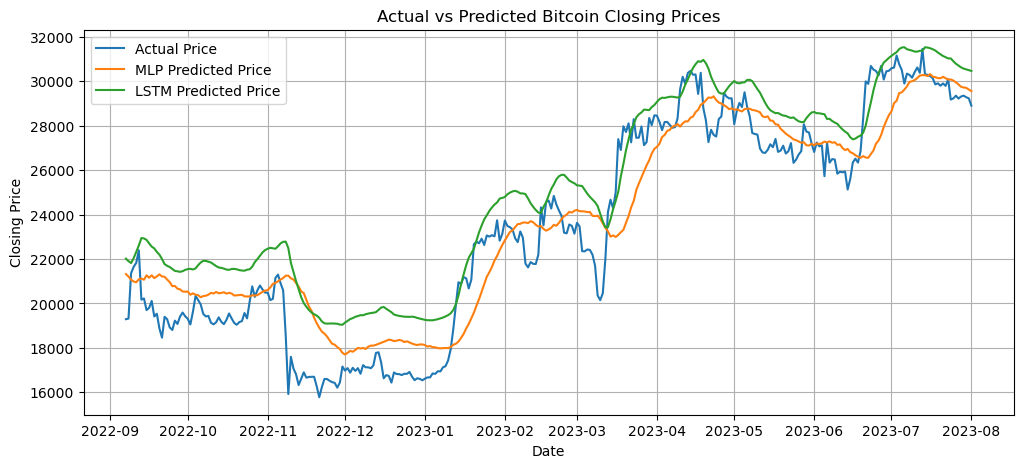

In [21]:
test_dates = df["timestamp"].iloc[SEQ_LEN + train_size:].reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(test_dates, actual, label="Actual Price")
plt.plot(test_dates, mlp_pred, label="MLP Predicted Price")
plt.plot(test_dates, lstm_pred, label="LSTM Predicted Price")
plt.title("Actual vs Predicted Bitcoin Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

## Part 22: Plot Training Loss Curves

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `plt.figure(...)` | Creates the chart area. |
| `plt.plot(mlp_losses, ...)` | Plots MLP training loss across epochs. |
| `plt.plot(lstm_losses, ...)` | Plots LSTM training loss across epochs. |
| `plt.title(...)` | Adds chart title. |
| `plt.xlabel("Epoch")` | Labels x-axis as training epoch. |
| `plt.ylabel("MSE Loss")` | Labels y-axis as loss value. |
| `plt.legend()` | Displays labels for both models. |
| `plt.grid(True)` | Adds grid lines. |
| `plt.show()` | Displays the chart. |

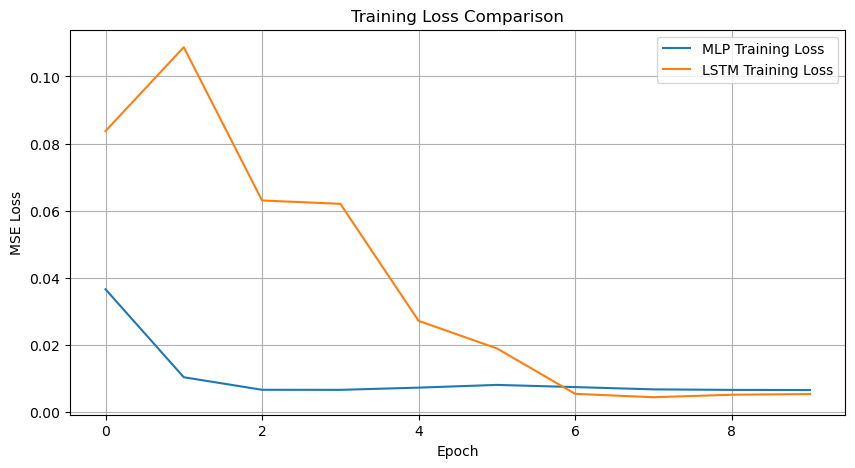

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_losses, label="MLP Training Loss")
plt.plot(lstm_losses, label="LSTM Training Loss")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

## Part 23: Display Sample Actual vs Predicted Values

### Detailed explanation of each code line

| Code line | Explanation |
|---|---|
| `comparison_df = pd.DataFrame(...)` | Creates a table containing actual and predicted prices. |
| `"Date": test_dates` | Adds the test date column. |
| `"Actual Close": actual.flatten()` | Adds actual closing prices. |
| `"MLP Prediction": mlp_pred.flatten()` | Adds MLP predicted prices. |
| `"LSTM Prediction": lstm_pred.flatten()` | Adds LSTM predicted prices. |
| `display(comparison_df.head(10).round(2))` | Displays the first 10 rows rounded to two decimals. |

In [23]:
comparison_df = pd.DataFrame({
    "Date": test_dates,
    "Actual Close": actual.flatten(),
    "MLP Prediction": mlp_pred.flatten(),
    "LSTM Prediction": lstm_pred.flatten()
})

display(comparison_df.head(10).round(2))

,Date,Actual Close,MLP Prediction,LSTM Prediction
0,2022-09-07,19292.84,21323.710938,22015.330078
1,2022-09-08,19319.77,21209.160156,21904.339844
2,2022-09-09,21360.11,21071.839844,21819.560547
3,2022-09-10,21648.34,20987.960938,22037.859375
4,2022-09-11,21826.87,20955.669922,22317.830078
5,2022-09-12,22395.74,21089.039062,22608.900391
6,2022-09-13,20173.57,21121.390625,22944.519531
7,2022-09-14,20226.71,21070.500000,22927.619141
8,2022-09-15,19701.88,21267.269531,22862.279297
9,2022-09-16,19803.30,21159.119141,22704.519531


# Business Interpretation and Final Answers

## 1. Why does volatility make cryptocurrency prediction hard?
Cryptocurrency prices are highly volatile because they are influenced by investor sentiment, regulation, macroeconomic events, liquidity changes, exchange activity, and unexpected news. This means price movements can change suddenly, making it difficult for any model to forecast accurately using historical prices only.

## 2. Why can better models assist traders and exchanges?
Better forecasting models can support financial decision-making by helping traders identify possible price trends, improve entry and exit timing, reduce portfolio risk, and detect potential trend reversals earlier. Exchanges may also use forecasting insights to understand market activity and manage operational risk.

## 3. Why might LSTM outperform MLP?
The LSTM model is designed for sequential data. It processes the previous 30 days as an ordered time sequence and can learn temporal dependencies. The MLP receives the same 30 days as flattened features, but it does not naturally understand the order of time. Therefore, LSTM is generally more suitable for forecasting tasks.

## 4. Which model performed better?
The better model is the one with lower MSE, MAE, and MAPE on the test dataset. If the LSTM has lower error values and follows the actual price line more closely, it provides stronger forecasting performance. If the MLP performs similarly or better in this run, this may be due to the short training period, simple model structure, or the noisy nature of Bitcoin prices.

## 5. What are the limitations of this project?
The model uses only historical closing prices. It does not include external factors such as market news, interest rates, regulation, blockchain activity, sentiment, or macroeconomic indicators. The model is also simple and trained for only 10 epochs, so it may not capture all complex price behaviours.

## 6. Ethical AI considerations
Forecasting models should not be presented as guaranteed financial advice. Users should understand that predictions are uncertain and can be wrong. Ethical use requires transparency, clear documentation, careful communication of risk, and avoidance of misleading claims. Financial AI models should support human decision-making rather than replace professional judgement.

## 7. Suggested improvements
Forecasting accuracy could be improved by adding more features such as open, high, low, volume, technical indicators, market sentiment, and macroeconomic data. The model could also be improved using more epochs, dropout regularisation, validation monitoring, deeper LSTM layers, GRU models, Transformer models, and systematic hyperparameter tuning.